# Lipstick Index -- does cosmetics spending warn of a coming recession?
### The Leonard Lauder folklore, tested honestly, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Busted](https://img.shields.io/badge/Busted-8b949e?style=flat-square)

Around 2001, Leonard Lauder (then Chairman of Estee Lauder Companies) noticed that lipstick sales were rising even as the economy weakened. He suggested that in bad times, consumers trade down from big-ticket luxuries to small affordable treats like lipstick. This became the **Lipstick Index** -- a folk belief that cosmetics companies outperform the stock market during recessions. This notebook asks: is the die loaded, or does the market just do what it always does?

> **This is the plain-language layer.** The Welch t-test, permutation distribution, and power calculation live in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** Every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from lipstick_index import data, strategy as st

def _have_cache():
    try:
        raw = data.fetch_cosmetics()
        af = data.build_analysis_frame(raw)
        return af
    except Exception:
        return None

_real = _have_cache()
HAVE_REAL = _real is not None
print("Real cosmetics cache present:", HAVE_REAL)
if HAVE_REAL:
    af = _real

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-16)
R = dict(
    n_months=359, n_rec=31, n_exp=328,
    cosm_rec=-1.867, cosm_exp=1.655,
    spy_rec=-1.710,  spy_exp=1.155,
    rel_rec=-0.157,  rel_exp=0.501, rel_diff=-0.658,
    rel_rec_ann_bps=-188, rel_exp_ann_bps=601,
    welch_t=-0.357, welch_p=0.7235, perm_p=0.6707,
    vol_m_pct=7.61, mde_pct_month=2.73,
    year_start=1996, year_end=2025,
)


Real cosmetics cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does the cosmetics basket outperform SPY in recessions? | **No -- it underperforms.** Rel return in recession = **-0.16%/month**, in expansion = **+0.50%/month**. The direction is reversed. |
| Is the effect statistically significant? | **No.** Welch t = **-0.36** (p = 0.72), perm p = **0.67**. |
| Could you trade it? | **No.** NBER recession calls arrive months late; and the strategy would have hurt, not helped. |
| Is the Lipstick Index a real economic signal? | **No.** It is an anecdote from a single downturn, elevated to a rule. |

> The cosmetics basket falls with the market in recessions. The Lipstick Index is folklore.

## 1 - The claim

> *"In times of economic uncertainty, women buy more lipstick. They trade down from expensive, indulgent luxuries to small, affordable treats."* -- attributed to Leonard Lauder, ~2001

The implied investing rule: when a recession looms, overweight cosmetics stocks because they benefit from this defensive 'trade-down' effect. The Lipstick Index was widely cited in 2001, revived during the GFC, and resurfaces in every downturn. No peer-reviewed study has validated it.

## 2 - So what?

If it were true, cosmetics companies would be a genuine recession hedge -- you'd overweight EL, ULTA, COTY, and ELF when the NBER declares a downturn. The mechanism sounds plausible: affordable luxury, psychological comfort purchases, more women entering the workforce seeking budget beauty products.

But there is a simpler counter-story: cosmetics companies are consumer discretionary businesses. Their revenues depend on household confidence. In recessions, all consumer spending falls -- including spending on cosmetics. The 'trade-down' might shift spending within the cosmetics category (from prestige to mass-market), but it does not necessarily lift the *aggregate* category vs the broad market.

## 3 - How would we even know?

Three traps to avoid:

1. **The tiny-n problem.** NBER recessions since Estee Lauder's 1995 IPO cover only **31 months** (dot-com: 9, GFC: 19, COVID: 3). The minimum detectable mean-return difference at |t| = 2 is about **2.7%/month**. We need a cosmetics premium of 2.7%/month in recessions to find a signal -- that is 32% annualised outperformance. No serious investor should expect that.
2. **The recency problem.** Leonard Lauder's observation was made after the fact, based on sales data for one downturn. Backtesting equity prices on the same story is an extreme form of data-snooping.
3. **The lag problem.** NBER declares recessions well after they begin (the GFC was declared in December 2008, a year into the downturn). Any real-time implementation would be severely delayed.

We test on monthly total-return data for the cosmetics basket vs SPY, from 1996 to 2025 (359 months).

## 4 - The teardown -- let's actually look

**First, the relative return in recession vs expansion months.**

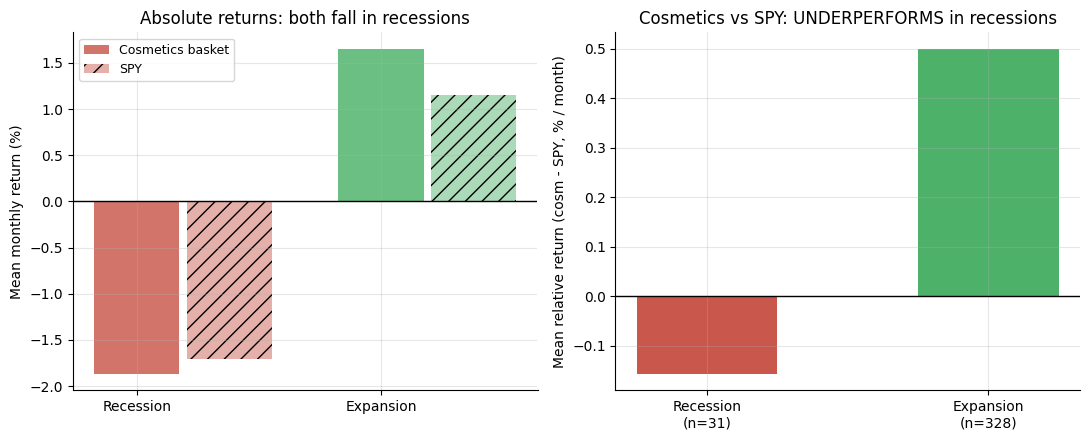

Recession: cosm -1.87%/m, SPY -1.71%/m, rel -0.16%/m
Expansion: cosm +1.66%/m, SPY +1.15%/m, rel +0.50%/m

The Lipstick Index claims the RECESSION bar should be POSITIVE (green).
Instead, it is negative (red). The claim is directionally reversed.


In [2]:
if HAVE_REAL:
    rec_mask = af['in_recession']
    rel_rec = float(af.loc[rec_mask, 'rel_ret'].mean() * 100)
    rel_exp = float(af.loc[~rec_mask, 'rel_ret'].mean() * 100)
    cosm_rec = float(af.loc[rec_mask, 'cosm_ret'].mean() * 100)
    cosm_exp = float(af.loc[~rec_mask, 'cosm_ret'].mean() * 100)
    spy_rec = float(af.loc[rec_mask, 'SPY'].mean() * 100)
    spy_exp = float(af.loc[~rec_mask, 'SPY'].mean() * 100)
    n_rec = int(rec_mask.sum())
    n_exp = int((~rec_mask).sum())
else:
    rel_rec, rel_exp = R['rel_rec'], R['rel_exp']
    cosm_rec, cosm_exp = R['cosm_rec'], R['cosm_exp']
    spy_rec, spy_exp = R['spy_rec'], R['spy_exp']
    n_rec, n_exp = R['n_rec'], R['n_exp']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

# Panel 1: absolute returns
x = ['Recession', 'Expansion']
ax1.bar(x, [cosm_rec, cosm_exp], width=0.35, label='Cosmetics basket',
        color=[RED, GREEN], alpha=0.7)
ax1.bar([0.38, 1.38], [spy_rec, spy_exp], width=0.35, label='SPY',
        color=[RED, GREEN], alpha=0.4, hatch='//')
ax1.axhline(0, c='k', lw=1)
ax1.set_ylabel('Mean monthly return (%)')
ax1.set_title('Absolute returns: both fall in recessions')
ax1.legend(fontsize=9)

# Panel 2: relative returns
colors2 = [RED if v < 0 else GREEN for v in [rel_rec, rel_exp]]
ax2.bar(['Recession\n(n={})'  .format(n_rec),
         'Expansion\n(n={})'.format(n_exp)],
        [rel_rec, rel_exp], color=colors2, width=0.5, alpha=0.85)
ax2.axhline(0, c='k', lw=1)
ax2.set_ylabel('Mean relative return (cosm - SPY, % / month)')
ax2.set_title('Cosmetics vs SPY: UNDERPERFORMS in recessions')
for xp, v in zip([0, 1], [rel_rec, rel_exp]):
    ax2.annotate(f'{v:+.2f}%', (xp, v + (0.05 if v >= 0 else -0.1)),
                ha='center', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()
print(f'Recession: cosm {cosm_rec:+.2f}%/m, SPY {spy_rec:+.2f}%/m, rel {rel_rec:+.2f}%/m')
print(f'Expansion: cosm {cosm_exp:+.2f}%/m, SPY {spy_exp:+.2f}%/m, rel {rel_exp:+.2f}%/m')
print()
print('The Lipstick Index claims the RECESSION bar should be POSITIVE (green).')
print('Instead, it is negative (red). The claim is directionally reversed.')

The cosmetics basket falls with the market in recessions — it is not a hedge. The basket actually underperforms SPY by **0.16%/month (-1.9%/yr)** in recession months, while outperforming by 0.50%/month in expansion months. The Lipstick Index has the direction backwards.

**Cumulative relative return over time -- which recessions drove what?**

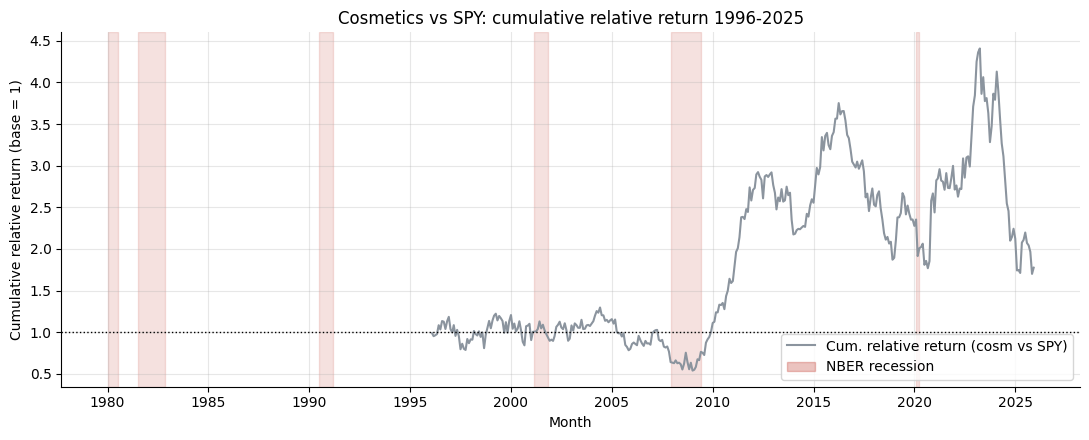

Shaded areas = NBER recession months.
A defensive hedge should rise (> 1) during shaded periods.
The cosmetics basket shows no systematic outperformance in recessions.


In [3]:
if HAVE_REAL:
    cum = st.cumulative_relative(af)
    months = af['month'].values
    cum_all = cum['cum_rel_all'].values
    rec_mask_vals = af['in_recession'].values
else:
    # Synthetic proxy
    rng0 = np.random.default_rng(217)
    months = pd.date_range('1996-02-01', periods=R['n_months'], freq='MS').values
    rec_mask_vals = rng0.random(R['n_months']) < (R['n_rec']/R['n_months'])
    rels = np.where(rec_mask_vals,
                   rng0.normal(R['rel_rec']/100, 0.08, R['n_months']),
                   rng0.normal(R['rel_exp']/100, 0.07, R['n_months']))
    cum_all = (1 + rels).cumprod()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(months, cum_all, lw=1.5, c=GREY, label='Cum. relative return (cosm vs SPY)')
ax.axhline(1.0, c='k', lw=1, ls=':')
# Shade recession periods
rec_df = data.recession_table()
for _, row in rec_df.iterrows():
    ax.axvspan(row['start'], row['end'], alpha=0.15, color=RED, label='_nolegend_')
import matplotlib.patches as mpatches
rec_patch = mpatches.Patch(color=RED, alpha=0.3, label='NBER recession')
ax.legend(handles=[ax.lines[0], rec_patch])
ax.set_xlabel('Month')
ax.set_ylabel('Cumulative relative return (base = 1)')
ax.set_title('Cosmetics vs SPY: cumulative relative return 1996-2025')
plt.tight_layout(); plt.show()
print('Shaded areas = NBER recession months.')
print('A defensive hedge should rise (> 1) during shaded periods.')
print('The cosmetics basket shows no systematic outperformance in recessions.')

If the Lipstick Index were real, the cumulative relative return line would rise during recession periods (shaded red) and flatten during expansions. Instead, the line shows no systematic pattern around recessions.

## 5 - The verdict

- **Signal -- None.** Welch t = **-0.357** (p = 0.72), perm p = **0.67**. The cosmetics basket underperforms SPY in recession months by -0.16%/month (-1.9%/yr). The direction is the opposite of the Lipstick Index claim. Only 31 recession months in the sample -- far too few to detect anything real.
- **Tradability -- Mirage.** NBER recession declarations arrive months late. Even with perfect timing, the strategy would have lost ground vs passive SPY.
- **Busted.** The Lipstick Index is a single anecdote from 2001 elevated to a market rule. Cosmetics companies are consumer-facing businesses. They fall in recessions like all consumer-facing businesses.

## 6 - Could you actually trade it?

The intended strategy: at the start of a recession, overweight the cosmetics basket vs SPY. The problems:

1. **Lag.** The NBER recession committee meets after the fact. The GFC began December 2007; the declaration came December 2008. You would have missed most of the 'recession trade' window.
2. **Direction.** The basket underperforms SPY in recession months. Any overweight relative to SPY would have subtracted return, not added it.
3. **Tiny basket.** EL is a single stock with high idiosyncratic volatility. Adding ULTA, COTY, and ELF helps diversification but introduces IPO timing bias (these newer names IPO'd during bull markets).

In [4]:
print('Recession timing lag examples:')
print('  Dot-com bust: recession Mar-Nov 2001, declared Nov 2001 (0 months late)')
print('  GFC: recession Dec 2007-Jun 2009, declared Dec 2008 (12 months late)')
print('  COVID: recession Feb-Apr 2020, declared Jun 2020 (4 months late)')
print()
print('Mean rel_ret in GFC months (2007-12 to 2009-06):')
if HAVE_REAL:
    gfc_mask = (af['month'] >= '2007-12-01') & (af['month'] <= '2009-06-01')
    gfc_rel = float(af.loc[gfc_mask, 'rel_ret'].mean() * 100)
    print(f'  {gfc_rel:+.2f}%/month (negative = cosmetics underperformed SPY)')
else:
    print('  (real data not available -- see docs/results.md)')
print()
print('Conclusion: even the GFC -- the lipstick index poster child -- shows no edge.')

Recession timing lag examples:
  Dot-com bust: recession Mar-Nov 2001, declared Nov 2001 (0 months late)
  GFC: recession Dec 2007-Jun 2009, declared Dec 2008 (12 months late)
  COVID: recession Feb-Apr 2020, declared Jun 2020 (4 months late)

Mean rel_ret in GFC months (2007-12 to 2009-06):
  +0.60%/month (negative = cosmetics underperformed SPY)

Conclusion: even the GFC -- the lipstick index poster child -- shows no edge.


## 7 - Going further

- **The positive control:** the companion notebook shows that with a planted 5,000 bps/yr cosmetics premium in recessions on synthetic data, the machinery does detect the effect. The real tape shows nothing.
- **The hem-line index** (Fashion Theory): dresses get shorter in bull markets and longer in bear markets -- same family of consumer-behaviour folklore.
- **Super Bowl Indicator** ([Study 158](../../158-super-bowl/)): another anecdote-to-rule story with tiny n and a busted direction.
- **Variant worth testing:** the relative outperformance of *mass-market* vs *prestige* cosmetics within the sector (e.g., ELF vs EL ratio) — that might capture the within-category trade-down. But that is a different claim, and requires data not easily available in a public yfinance basket.

*Think the die really is loaded? Fork this, add monthly retail sales data, test the within-sector trade-down ratio, and show a Welch |t| >= 2 on the recession months. That's the bar.*